<a href="https://colab.research.google.com/github/ehas1/Statistical-Bias-in-ML/blob/main/LIME_and_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
! pip install lime
import lime.lime_tabular
import shap

import xgboost as xgb
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
import os
import glob
import joblib
from pathlib import Path
import requests
from io import StringIO

# Visualization Settings
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Global Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [34]:
# Storage and Model Loading Setup
def setup_storage():
    """Set up storage access for model files."""
    # First try the local COMPAS_models directory in the current working directory
    models_dir = os.path.join(os.getcwd(), 'COMPAS_models')

    if not os.path.exists(models_dir):
        # Try home directory
        models_dir = os.path.join(os.path.expanduser('~'), 'Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models')

    # Create the models directory if it doesn't exist
    if not os.path.exists(models_dir):
        os.makedirs(models_dir)
        print(f"Created models directory at {models_dir}")

    print(f"Using models directory: {models_dir}")
    return models_dir

def find_latest_model(pattern: str, models_dir: str = None) -> str:
    """Find the most recent model file matching the given pattern."""
    # Try multiple possible paths
    colab_path = "/content/gdrive/MyDrive/COMPAS_models"
    local_path = os.path.join(os.path.expanduser('~'), 'COMPAS_models')
    current_dir_path = os.path.join(os.getcwd(), 'COMPAS_models')

    # Use provided models_dir, or try all possible paths
    search_paths = [p for p in [models_dir, colab_path, local_path, current_dir_path] if p]

    print(f"\nSearching for pattern: {pattern}")
    print("Checking directories:")

    for path in search_paths:
        print(f"Checking {path}...")
        if os.path.exists(path):
            print(f"Directory exists: {path}")
            # List all files in directory
            print("Files in directory:")
            for f in os.listdir(path):
                print(f"  - {f}")

            # Try to find matching files
            full_pattern = os.path.join(path, pattern)
            files = glob.glob(full_pattern)
            if files:
                print(f"Found files matching {pattern}:")
                for f in files:
                    print(f"  - {f}")
                latest = max(files, key=os.path.getctime)
                print(f"Selected latest file: {latest}")
                # Check if it's a metadata file
                if 'metadata' in latest:
                    print("Warning: Selected file is a metadata file, skipping...")
                    continue
                return latest
        else:
            print(f"Directory does not exist: {path}")

    raise FileNotFoundError(f"No model files found matching pattern: {pattern}")

def load_all_models() -> tuple:
    """Load all models including bias-specific decision trees."""
    try:
        models_dir = setup_storage()
        # Load bias-specific decision tree models
        sex_bias_model_path = find_latest_model('sex_bias_decision_tree_model_*[!metadata].joblib')
        racial_bias_model_path = find_latest_model('racial_bias_decision_tree_model_*[!metadata].joblib')

        # Try to find XGBoost model with different possible extensions
        try:
            xgb_model_path = find_latest_model('xgboost_model_*[!metadata].ubj')
        except FileNotFoundError:
            try:
                xgb_model_path = find_latest_model('xgboost_model_*[!metadata].json')
            except FileNotFoundError:
                xgb_model_path = find_latest_model('xgboost_model_*[!metadata].*')

        nn_model_path = find_latest_model('neural_network_model_*.keras')

        print("Loading models from:")
        print(f"Sex Bias Decision Tree: {sex_bias_model_path}")
        print(f"Racial Bias Decision Tree: {racial_bias_model_path}")
        print(f"XGBoost: {xgb_model_path}")
        print(f"Neural Network: {nn_model_path}")

        # Load decision tree models
        sex_bias_model = joblib.load(sex_bias_model_path)
        racial_bias_model = joblib.load(racial_bias_model_path)
        print("Successfully loaded bias-specific decision tree models")

        # Load XGBoost model
        try:
            wrapped_xgb = xgb.XGBClassifier(
                objective='binary:logistic',
                use_label_encoder=False
            )
            wrapped_xgb.load_model(str(xgb_model_path))
            print("Successfully loaded XGBoost model")
        except Exception as e:
            print(f"Error loading XGBoost model: {str(e)}")
            try:
                print("Attempting alternative loading method...")
                booster = xgb.Booster()
                booster.load_model(str(xgb_model_path))
                wrapped_xgb = xgb.XGBClassifier(
                    objective='binary:logistic',
                    use_label_encoder=False
                )
                wrapped_xgb._Booster = booster
                wrapped_xgb.n_classes_ = 2
                print("Successfully loaded XGBoost model using alternative method")
            except Exception as e2:
                print(f"Alternative loading method also failed: {str(e2)}")
                raise

        # Load Neural Network model
        nn_model = load_model(nn_model_path)
        print("Successfully loaded Neural Network model")

        return sex_bias_model, racial_bias_model, wrapped_xgb, nn_model

    except Exception as e:
        print(f"Error loading models: {str(e)}")
        print("Please ensure the models are saved in either:")
        print("- Google Colab: /content/drive/MyDrive/COMPAS_models/")
        print(f"- Local: {os.path.join(os.path.expanduser('~'), 'COMPAS_models')}")
        raise

# Set up storage and update the global models directory
MODELS_DIR = setup_storage()

# Load all models
sex_bias_model, racial_bias_model, xgb_model, nn_model = load_all_models()

# Create models dictionary
models_dict = {
    'sex_bias_dt': sex_bias_model,
    'racial_bias_dt': racial_bias_model,
    'xgb': xgb_model,
    'nn': nn_model
}


Using models directory: /root/Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models
Using models directory: /root/Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models

Searching for pattern: sex_bias_decision_tree_model_*[!metadata].joblib
Checking directories:
Checking /content/gdrive/MyDrive/COMPAS_models...
Directory exists: /content/gdrive/MyDrive/COMPAS_models
Files in directory:
  - decision_tree_model_20250806_005108.joblib
  - decision_tree_model_20250806_005108_metadata.json
  - xgboost_model_20250902_150408.joblib
  - xgboost_model_20250902_150408_metadata.json
  - neural_network_model_20250902_150755.keras
  - neural_network_model_20250902_150755_metadata.json
  - racial_bias_decision_tree_model_20250902_163708_metadata.json
  - racial_bias_decision_tree_model_20250902_163708.joblib
  - sex_bias_decision_tree_model_20250902_163709.joblib
  - sex_bias_decision_tree_model_20250902_163709_metadata.json
Found files matching sex_bias_decision_tree_model_*[!metadata].joblib:
  - /content

In [35]:
# Data Loading and Preprocessing Functions
def load_data(url="https://raw.githubusercontent.com/propublica/compas-analysis/refs/heads/master/cox-violent-parsed.csv"):
    """Load the COMPAS dataset from ProPublica's repository."""
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = pd.read_csv(StringIO(response.text))
        print(f"Successfully loaded data with shape: {data.shape}")
        return data
    except Exception as e:
        print(f"Error loading data: {str(e)}")
        raise

def preprocess_data(data):
    """Preprocess the COMPAS dataset for model interpretation."""
    # Print available columns for debugging
    print("Available columns in dataset:", data.columns.tolist())

    # Define required columns and their expected categories
    required_features = [
        'age',
        'c_charge_degree',
        'race',
        'sex',
        'priors_count',
        'juv_other_count',
        'juv_fel_count',
        'juv_misd_count',
        'decile_score'
    ]
    target = 'is_recid'

    # Define expected categories for categorical variables
    expected_categories = {
        'c_charge_degree': ['F', 'M'],  # Felony and Misdemeanor
        'race': ['African-American', 'Caucasian', 'Hispanic', 'Other'],
        'sex': ['Female', 'Male']
    }

    # Define the exact expected feature set for the neural network (14 features)
    expected_features = [
        # Numerical features
        'age', 'priors_count',
        # Charge degree features (all categories)
        'c_charge_degree_F', 'c_charge_degree_M',
        # Race features (all categories)
        'race_African-American', 'race_Caucasian', 'race_Hispanic', 'race_Other',
        # Sex features (all categories)
        'sex_Female', 'sex_Male',
        # Additional features that might be expected by the model
        'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'decile_score'
    ]

    # Validate required columns exist
    missing_cols = [col for col in required_features + [target] if col not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # Preprocessing pipeline
    print("\nPreprocessing steps:")

    # 1. Handle missing values
    print("1. Handling missing values...")
    for col in required_features:
        if data[col].isnull().any():
            if pd.api.types.is_numeric_dtype(data[col]):
                data[col].fillna(data[col].mean(), inplace=True)
            else:
                data[col].fillna(data[col].mode()[0], inplace=True)

    # 2. Convert categorical variables with controlled encoding
    print("2. Converting categorical variables...")
    data_processed = data[required_features].copy()

    # Ensure categories are mapped correctly
    data_processed['race'] = data_processed['race'].map(lambda x: 'Other' if x not in expected_categories['race'] else x)
    data_processed['c_charge_degree'] = data_processed['c_charge_degree'].map(lambda x: 'F' if x not in expected_categories['c_charge_degree'] else x)
    data_processed['sex'] = data_processed['sex'].map(lambda x: 'Male' if x not in expected_categories['sex'] else x)

    # First handle numerical features
    numerical_features = ['age', 'priors_count', 'decile_score']

    # Create a new DataFrame with just numerical features
    data_processed_new = pd.DataFrame()

    # Add numerical features
    for feature in numerical_features:
        if feature in data.columns:
            data_processed_new[feature] = data[feature]
        else:
            print(f"Warning: {feature} not found in data, filling with zeros")
            data_processed_new[feature] = 0

    # Create dummy variables for categorical features
    for cat_col, categories in expected_categories.items():
        # Create dummy variables
        dummies = pd.get_dummies(
            data_processed[cat_col],
            prefix=cat_col,
            prefix_sep='_'
        )

        # Ensure all expected categories exist
        for category in categories:
            col_name = f"{cat_col}_{category}"
            if col_name not in dummies.columns:
                dummies[col_name] = 0

        # Add to processed data
        data_processed_new = pd.concat([data_processed_new, dummies], axis=1)

    # Ensure all expected features are present and in correct order
    missing_features = set(expected_features) - set(data_processed_new.columns)
    if missing_features:
        print(f"Warning: Adding missing features: {missing_features}")
        for feature in missing_features:
            data_processed_new[feature] = 0

    # Reorder columns to match expected feature order
    data_processed = data_processed_new[expected_features]

    print("\nVerifying features:")
    print(f"Expected features: {len(expected_features)}")
    print(f"Actual features: {len(data_processed.columns)}")
    print("\nFeatures in processed data:")
    for i, col in enumerate(data_processed.columns, 1):
        print(f"{i}. {col}")

    # Print the expected feature set
    print("\nFeature set after preprocessing:")
    print(data_processed.columns.tolist())

    # 3. Normalize numerical features
    print("3. Normalizing numerical features...")
    numerical_features = ['age', 'priors_count', 'decile_score']
    for col in numerical_features:
        data_processed[col] = (data_processed[col] - data_processed[col].mean()) / data_processed[col].std()

    # 4. Split into features and target
    print("4. Preparing train-test split...")
    # Convert to float32 for neural network compatibility
    X = data_processed.astype(np.float32)
    y = data[target]

    # Print feature columns for verification
    print("\nFeature columns after preprocessing:")
    print(X.columns.tolist())
    print(f"Number of features: {len(X.columns)}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\nPreprocessing complete:")
    print(f"Training set shape: {X_train.shape}")
    print(f"Test set shape: {X_test.shape}")

    return (X_train, y_train), (X_test, y_test)

# Load and preprocess data
print("Loading and preprocessing data...")
data = load_data()
(X_train, y_train), (X_test, y_test) = preprocess_data(data)
feature_names = X_train.columns.tolist()


Loading and preprocessing data...
Successfully loaded data with shape: (18316, 52)
Available columns in dataset: ['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event']

Preprocessing steps:
1. Handling missing values...
2. Converting categori

/tmp/ipython-input-86841138.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [36]:
# Load models and verify compatibility
def verify_model_compatibility(X_sample, models):
    """Verify that the preprocessed data matches the expected input shapes of the models."""
    print("Verifying model compatibility...")

    # Get the number of features in the preprocessed data
    n_features = X_sample.shape[1]
    print(f"\nPreprocessed data has {n_features} features")
    print(f"Input data types:")
    for col in X_sample.columns:
        print(f"  {col}: {X_sample[col].dtype}")

    # Convert data to numpy array and ensure float32 type
    X_single = X_sample.values[:1].astype(np.float32)

    # Check Sex Bias Decision Tree model
    try:
        sex_bias_pred = models['sex_bias_dt'].predict_proba(X_single)
        print("✓ Sex Bias Decision Tree model compatible")
        print(f"Sex Bias model prediction shape: {sex_bias_pred.shape}")
    except Exception as e:
        print(f"✗ Sex Bias Decision Tree model error: {str(e)}")

    # Check Racial Bias Decision Tree model
    try:
        racial_bias_pred = models['racial_bias_dt'].predict_proba(X_single)
        print("✓ Racial Bias Decision Tree model compatible")
        print(f"Racial Bias model prediction shape: {racial_bias_pred.shape}")
    except Exception as e:
        print(f"✗ Racial Bias Decision Tree model error: {str(e)}")

    # Check XGBoost model
    try:
        xgb_pred = models['xgb'].predict_proba(X_single)
        print("✓ XGBoost model compatible")
        print(f"XGBoost prediction shape: {xgb_pred.shape}")
    except Exception as e:
        print(f"✗ XGBoost model error: {str(e)}")

    # Check Neural Network model
    try:
        # Get input shape from the model's input layer
        nn_input_shape = models['nn'].input_shape[1]
        print(f"\nNeural Network expects {nn_input_shape} features")
        if nn_input_shape != n_features:
            print(f"✗ Neural Network input shape mismatch: expected {nn_input_shape}, got {n_features}")
            print("\nFeature columns in preprocessed data:")
            print(X_sample.columns.tolist())
            raise ValueError(f"Neural Network expects {nn_input_shape} features but got {n_features}")

        # Try prediction with proper data type
        nn_pred = models['nn'].predict(X_single)
        print("✓ Neural Network model compatible")
        print(f"Neural Network prediction shape: {nn_pred.shape}")
    except Exception as e:
        print(f"✗ Neural Network model error: {str(e)}")
        print("\nDebug information:")
        print(f"Input shape: {X_single.shape}")
        print(f"Input data type: {X_single.dtype}")
        print(f"Model summary:")
        models['nn'].summary()
        raise

# Verify compatibility of all models
print("Verifying model compatibility...")
verify_model_compatibility(X_train, models_dict)


Verifying model compatibility...
Verifying model compatibility...

Preprocessed data has 14 features
Input data types:
  age: float32
  priors_count: float32
  c_charge_degree_F: float32
  c_charge_degree_M: float32
  race_African-American: float32
  race_Caucasian: float32
  race_Hispanic: float32
  race_Other: float32
  sex_Female: float32
  sex_Male: float32
  juv_fel_count: float32
  juv_misd_count: float32
  juv_other_count: float32
  decile_score: float32
✓ Sex Bias Decision Tree model compatible
Sex Bias model prediction shape: (1, 2)
✓ Racial Bias Decision Tree model compatible
Racial Bias model prediction shape: (1, 2)
✓ XGBoost model compatible
XGBoost prediction shape: (1, 2)

Neural Network expects 14 features


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
✓ Neural Network model compatible
Neural Network prediction shape: (1, 1)


In [42]:
# LIME and SHAP Setup Functions
def setup_explainers(X_train, feature_names, models):
    """Set up LIME and SHAP explainers for all models"""
    # LIME explainer setup
    # Identify categorical features (those with _F, _M, etc. in name)
    categorical_features = [i for i, fname in enumerate(feature_names)
                          if any(x in fname for x in ['_F', '_M', '_Female', '_Male', '_African-American', '_Caucasian', '_Hispanic', '_Other'])]

    # Create LIME explainer with categorical features specified
    lime_exp = lime.lime_tabular.LimeTabularExplainer(
        X_train.values,
        feature_names=feature_names,
        class_names=['No Recidivism', 'Recidivism'],
        categorical_features=categorical_features,
        categorical_names={i: ['No', 'Yes'] for i in categorical_features},
        mode='classification',
        discretize_continuous=False,  # Don't discretize since we've already normalized
        sample_around_instance=False,  # Don't sample around instance to avoid scale issues
        kernel_width=0.75 * np.sqrt(X_train.shape[1]),  # Scale kernel width with feature count
        verbose=False
    )

    # SHAP explainers
    def nn_predict_wrapper(x):
        pred = models['nn'].predict(x.astype(np.float32))
        if pred.shape[1] == 1:
            # If single output, convert to two-class probability
            return np.hstack([1 - pred, pred])
        return pred

    shap_exp = {
        'sex_bias_dt': shap.TreeExplainer(models['sex_bias_dt']),
        'racial_bias_dt': shap.TreeExplainer(models['racial_bias_dt']),
        'xgb': shap.TreeExplainer(models['xgb']),
        'nn': shap.KernelExplainer(
            nn_predict_wrapper,
            shap.sample(X_train, 100, random_state=42),
            link="logit"
        )
    }

    return lime_exp, shap_exp

def plot_global_importance(X_train, lime_exp, shap_exp, models, feature_names, focus_bias=None):
    """
    Plot global feature importance using LIME and SHAP

    Parameters:
    -----------
    focus_bias : str, optional
        Can be 'sex', 'racial', or None. If specified, highlights features related to that type of bias.
    """
    # Define bias-related features
    sex_bias_features = ['sex_Female', 'sex_Male']
    racial_bias_features = ['race_African-American', 'race_Caucasian', 'race_Hispanic', 'race_Other']

    fig, axes = plt.subplots(2, 1, figsize=(15, 12))
    title = 'Global Feature Importance Comparison'
    if focus_bias:
        title += f' (Focus on {focus_bias.capitalize()} Bias)'
    fig.suptitle(title, fontsize=14)

    # SHAP importance
    plt.sca(axes[0])
    shap_values = {}
    for name, explainer in shap_exp.items():
        if focus_bias:
            if focus_bias == 'sex' and 'racial_bias' in name:
                continue
            if focus_bias == 'racial' and 'sex_bias' in name:
                continue

        data = X_train if name != 'nn' else shap.sample(X_train, 100)
        values = explainer.shap_values(data)
        if isinstance(values, list):
            values = values[1]
        shap_values[name] = np.abs(values).mean(0)

    # Plot SHAP importance with highlighting
    shap_df = pd.DataFrame(shap_values, index=feature_names)
    ax = shap_df.plot(kind='bar', ax=axes[0])
    axes[0].set_title('SHAP Global Feature Importance')
    axes[0].set_xlabel('Features')
    axes[0].set_ylabel('Mean |SHAP value|')

    # Highlight bias-related features
    if focus_bias:
        highlight_features = sex_bias_features if focus_bias == 'sex' else racial_bias_features
        for i, feature in enumerate(feature_names):
            if feature in highlight_features:
                ax.patches[i].set_facecolor('red')
                ax.patches[i].set_alpha(0.7)

    # LIME importance
    X_sample = X_train.sample(n=100, random_state=42)
    lime_values = {name: np.zeros(len(feature_names)) for name in models if not focus_bias or
                  (focus_bias == 'sex' and 'racial_bias' not in name) or
                  (focus_bias == 'racial' and 'sex_bias' not in name)}

    for x in X_sample.values:
        for name, model in models.items():
            if name not in lime_values:
                continue
            predict_fn = model.predict_proba if name != 'nn' else model.predict
            exp = lime_exp.explain_instance(x, predict_fn, num_features=len(feature_names))
            for feat, imp in exp.as_list():
                idx = feature_names.index(feat.split(' ')[0])
                lime_values[name][idx] += abs(imp)

    # Plot LIME importance with highlighting
    lime_df = pd.DataFrame(lime_values, index=feature_names)
    ax = lime_df.plot(kind='bar', ax=axes[1])
    axes[1].set_title('LIME Global Feature Importance')
    axes[1].set_xlabel('Features')
    axes[1].set_ylabel('Cumulative |importance|')

    # Highlight bias-related features
    if focus_bias:
        highlight_features = sex_bias_features if focus_bias == 'sex' else racial_bias_features
        for i, feature in enumerate(feature_names):
            if feature in highlight_features:
                ax.patches[i].set_facecolor('red')
                ax.patches[i].set_alpha(0.7)

    plt.tight_layout()
    plt.show()

def analyze_bias_impact(X_test, y_test, models, feature_names, bias_type='sex'):
    """
    Analyze the impact of bias-related features on model predictions

    Parameters:
    -----------
    bias_type : str
        Either 'sex' or 'racial'
    """
    # Select relevant features and model based on bias type
    if bias_type == 'sex':
        bias_features = ['sex_Female', 'sex_Male']
        bias_model = models['sex_bias_dt']
        model_name = 'Sex Bias DT'
    else:
        bias_features = ['race_African-American', 'race_Caucasian', 'race_Hispanic', 'race_Other']
        bias_model = models['racial_bias_dt']
        model_name = 'Racial Bias DT'

    # Get feature indices
    bias_indices = [feature_names.index(f) for f in bias_features]

    # Make predictions
    y_pred = bias_model.predict(X_test)

    # Calculate overall metrics
    from sklearn.metrics import classification_report, confusion_matrix
    print(f"\nModel Performance Analysis ({model_name}):")
    print("-" * 50)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Analyze predictions by protected attributes
    print(f"\nPrediction Distribution by {bias_type.capitalize()} Categories:")
    for feature in bias_features:
        feature_idx = feature_names.index(feature)
        subset_mask = X_test.iloc[:, feature_idx] == 1
        subset_pred = y_pred[subset_mask]
        subset_true = y_test[subset_mask]

        print(f"\n{feature} Analysis:")
        print(f"Total samples: {len(subset_pred)}")
        print(f"Predicted recidivism rate: {(subset_pred == 1).mean():.3f}")
        print(f"Actual recidivism rate: {(subset_true == 1).mean():.3f}")
        print("\nConfusion Matrix:")
        print(confusion_matrix(subset_true, subset_pred))

# Initialize explainers
print("Setting up LIME and SHAP explainers...")
lime_exp, shap_exp = setup_explainers(X_train, feature_names, models_dict)

# Print available models for analysis
print("\nAvailable models for analysis:")
for model_name in models_dict.keys():
    print(f"- {model_name}")



Setting up LIME and SHAP explainers...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

Available models for analysis:
- sex_bias_dt
- racial_bias_dt
- xgb
- nn



Analyzing 5 random instances...

Instance 1919 (True label: No Recidivism)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

Debug - Prediction shapes:
Sex Bias DT pred shape: (1, 2)
Racial Bias DT pred shape: (1, 2)
XGB pred shape: (1, 2)
NN pred shape: (1, 1)

Predictions:
----------------------------------------
SEX_BIAS_DT     : 0.340
RACIAL_BIAS_DT  : 0.685
XGB             : 0.917
NN              : 0.917


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



Debug info for sex_bias_dt:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)

SEX_BIAS_DT SHAP Values:
SHAP array shape: (14,)
  juv_other_count                : +0.170
  decile_score                   : -0.170
  sex_Male                       : +0.056
  sex_Female                     : -0.056
  age                            : -0.022
  priors_count                   : +0.022

Debug info for racial_bias_dt:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)

RACIAL_BIAS_DT SHAP Values:
SHAP array shape: (14,)
  sex_Female                     : -0.116
  sex_Male                       : +0.116
  priors_count                   : +0.055
  age                            : -0.055
  race_Hispanic                  : +0.010
  race_Other                     : -0.010


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



Debug info for xgb:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14)

XGB SHAP Values:
SHAP array shape: (14,)
  race_African-American          : +1.411
  age                            : +0.847
  c_charge_degree_F              : +0.163
  race_Other                     : +0.130
  race_Hispanic                  : -0.069
  race_Caucasian                 : +0.037
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 839us/step

Debug info for nn:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)

NN SHAP Values:
SHAP array shape: (14,)
  age                            : -1.048
  priors_count                   : +1.048
  sex_Male                       : +0.611
  sex_Female                     : -0.611
  c_charge_degree_M              : -0.076
  c_charge_degree_F              : +0.076


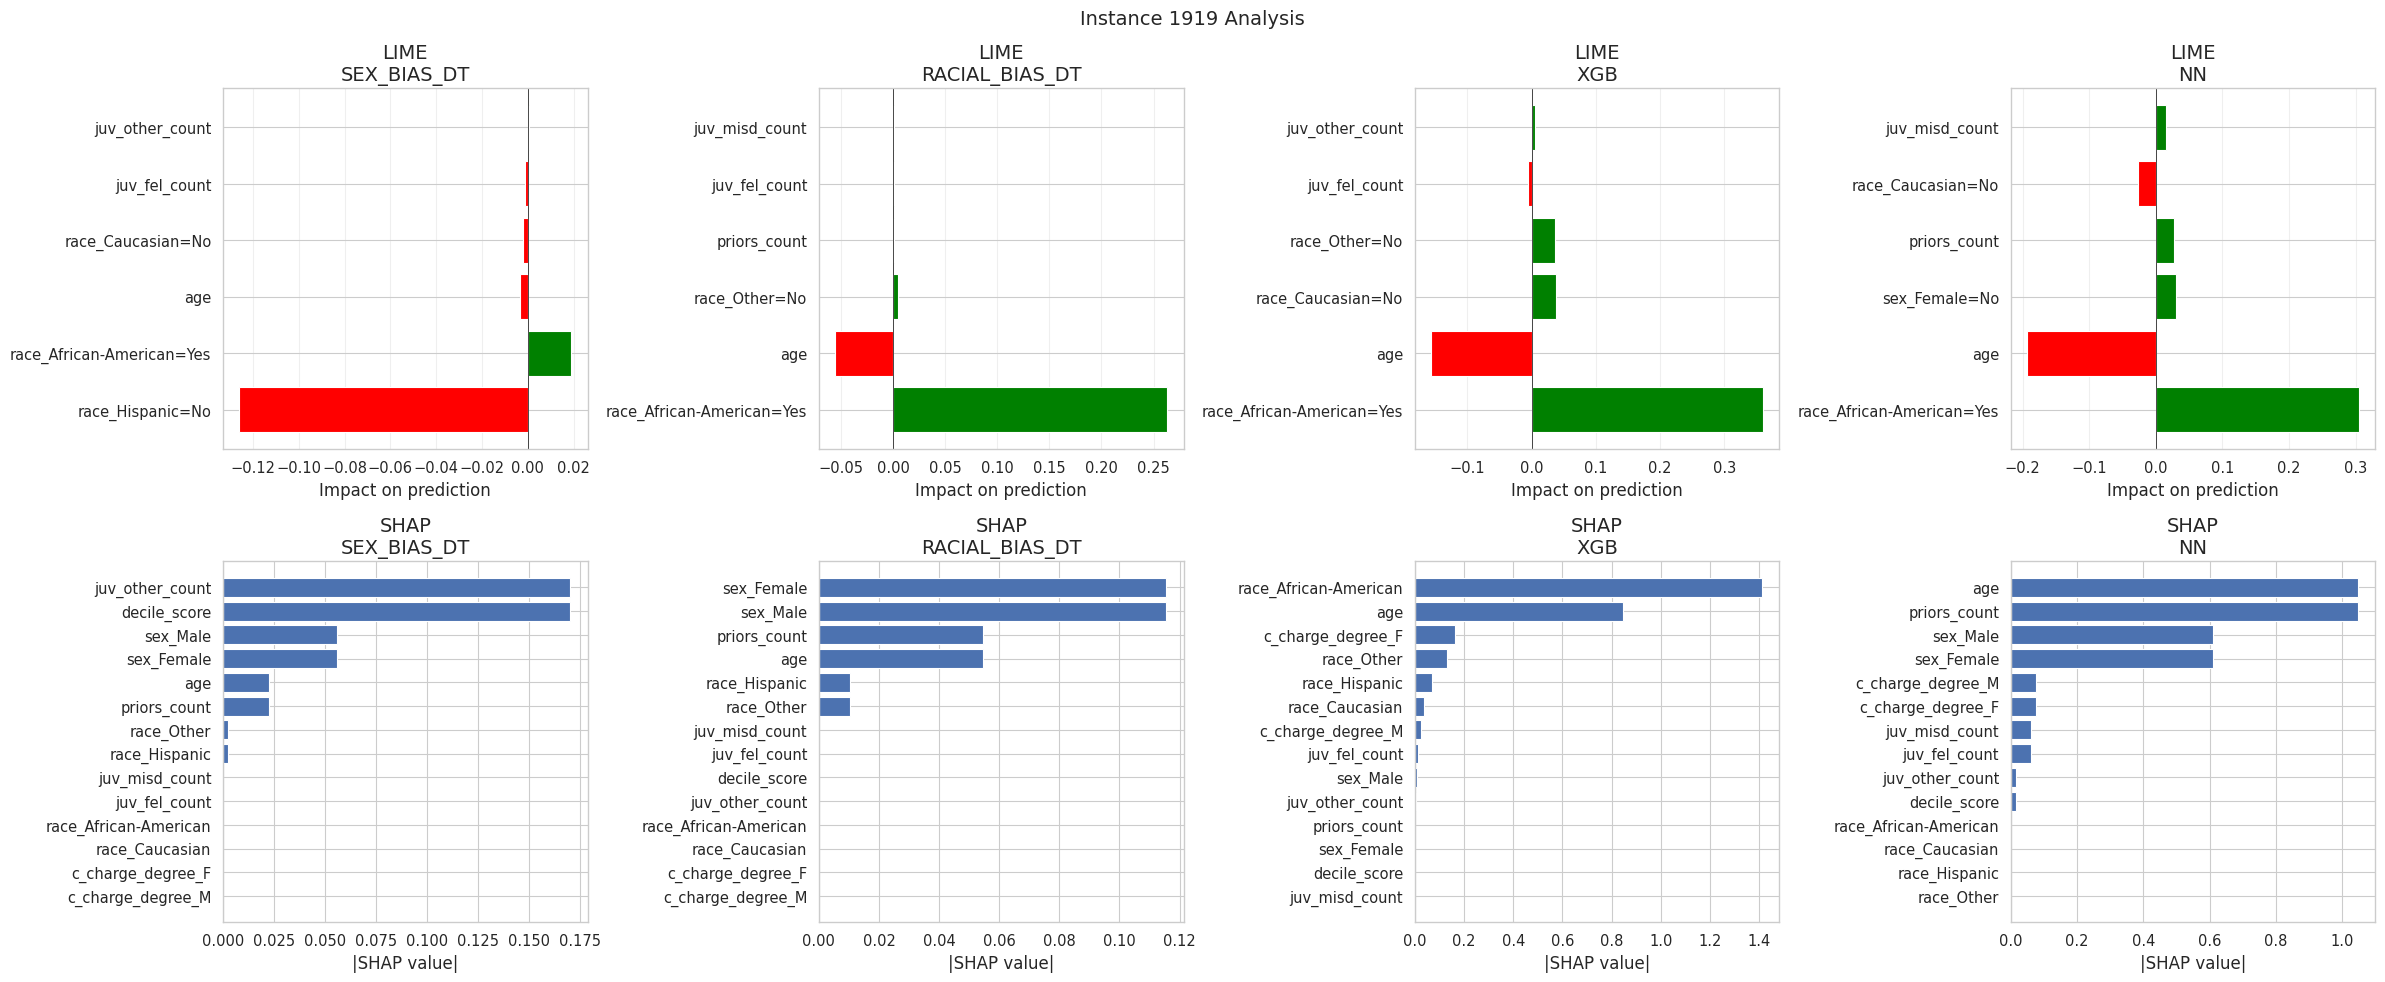


Instance 2972 (True label: No Recidivism)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

Debug - Prediction shapes:
Sex Bias DT pred shape: (1, 2)
Racial Bias DT pred shape: (1, 2)
XGB pred shape: (1, 2)
NN pred shape: (1, 1)

Predictions:
----------------------------------------
SEX_BIAS_DT     : 0.340
RACIAL_BIAS_DT  : 0.685
XGB             : 0.917
NN              : 0.924


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



Debug info for sex_bias_dt:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)


Exception ignored in: <function _xla_gc_callback at 0x79bebda17740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/lib/__init__.py", line 96, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



SEX_BIAS_DT SHAP Values:
SHAP array shape: (14,)
  juv_other_count                : +0.170
  decile_score                   : -0.170
  sex_Male                       : +0.056
  sex_Female                     : -0.056
  age                            : -0.022
  priors_count                   : +0.022

Debug info for racial_bias_dt:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)

RACIAL_BIAS_DT SHAP Values:
SHAP array shape: (14,)
  sex_Female                     : -0.116
  sex_Male                       : +0.116
  priors_count                   : +0.055
  age                            : -0.055
  race_Hispanic                  : +0.010
  race_Other                     : -0.010

Debug info for xgb:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14)

XGB SHAP Values:
SHAP array shape: (14,)
  race_African-American          : +1.411
  age                            : +0.847
  c_charge_degree_F              : +0.163
  race_Other                   

  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 890us/step

Debug info for nn:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)

NN SHAP Values:
SHAP array shape: (14,)
  priors_count                   : +1.169
  age                            : -1.169
  sex_Female                     : -0.608
  sex_Male                       : +0.608
  c_charge_degree_M              : -0.075
  c_charge_degree_F              : +0.075


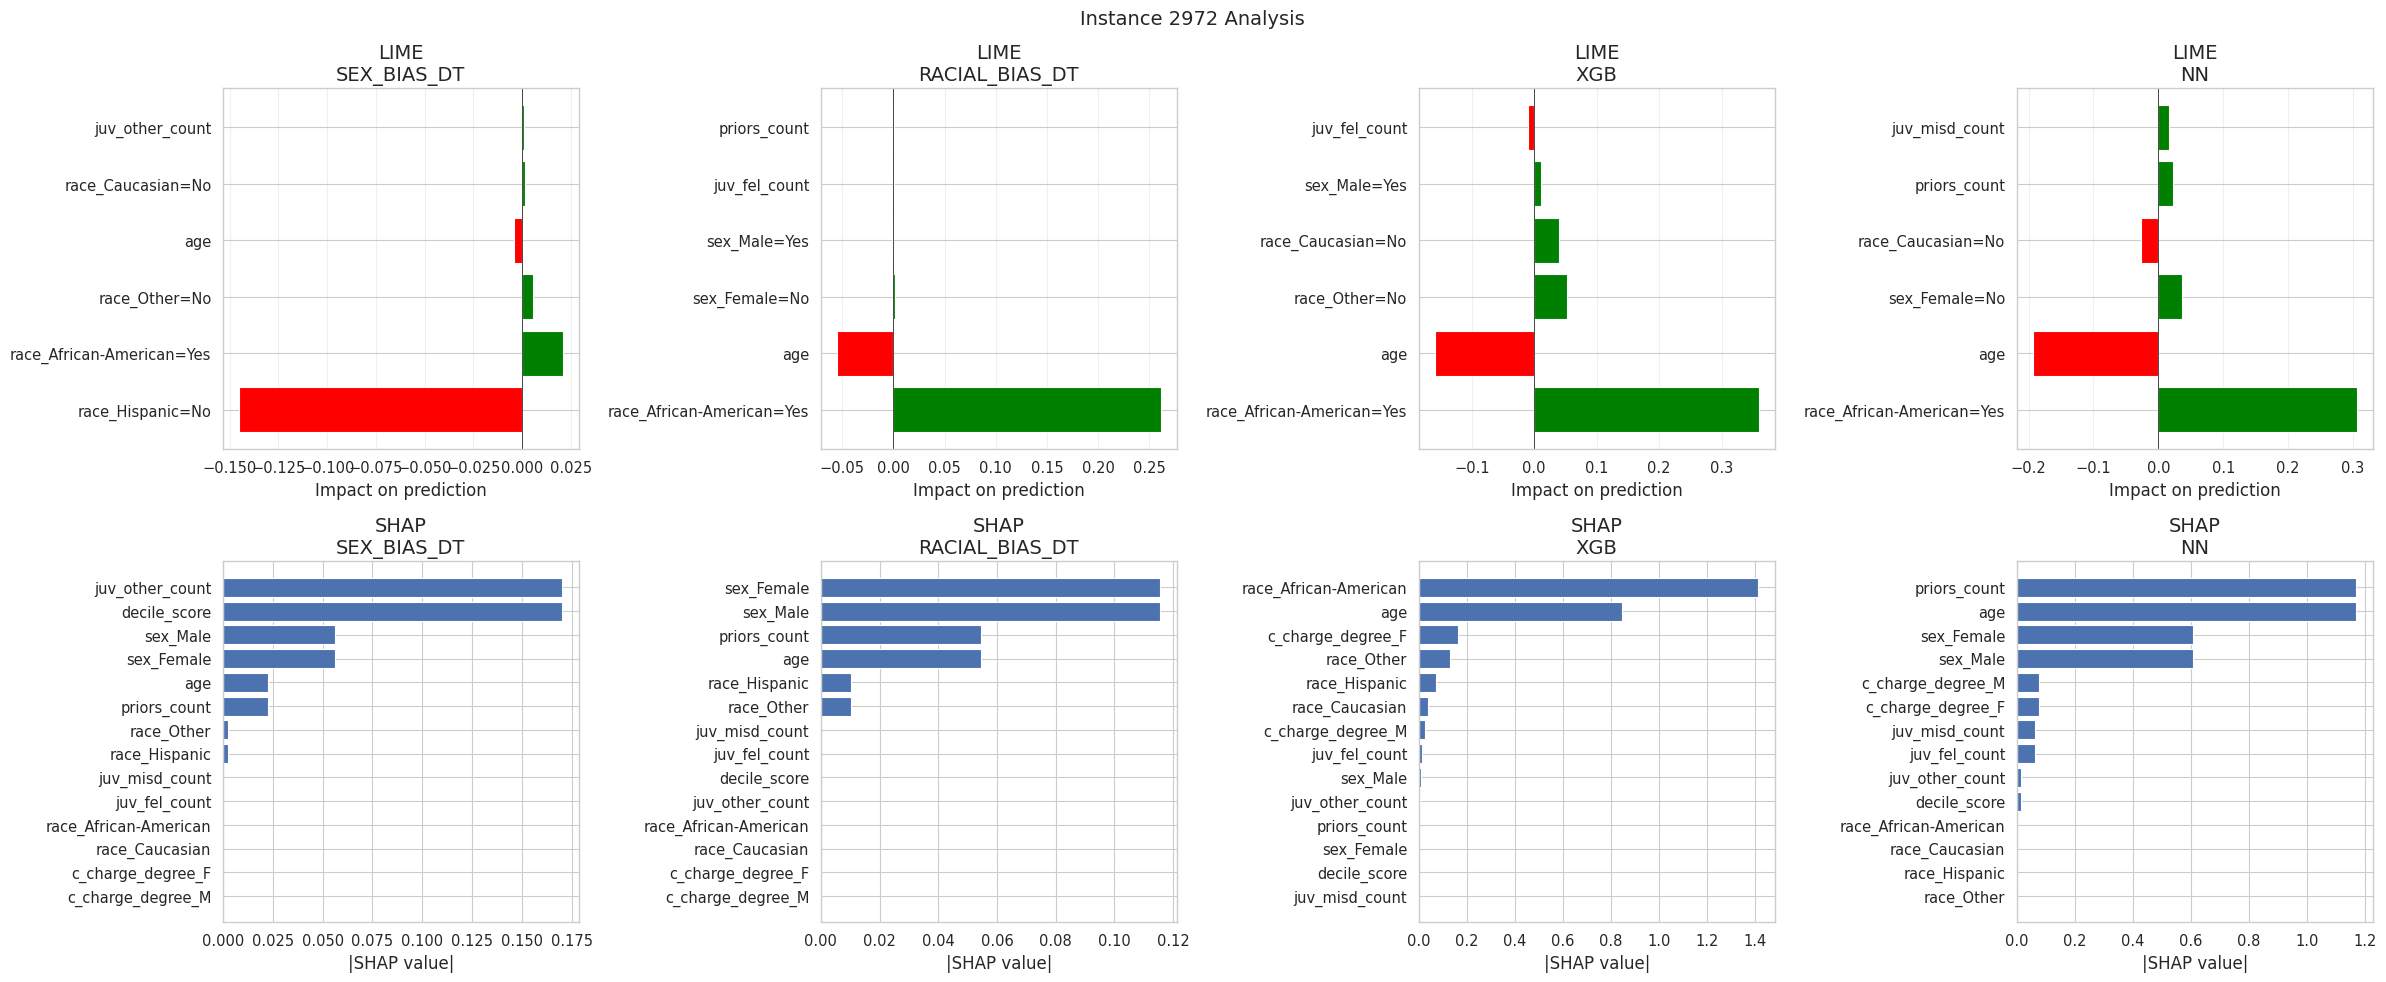


Instance 989 (True label: Recidivism)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Debug - Prediction shapes:
Sex Bias DT pred shape: (1, 2)
Racial Bias DT pred shape: (1, 2)
XGB pred shape: (1, 2)
NN pred shape: (1, 1)

Predictions:
----------------------------------------
SEX_BIAS_DT     : 0.340
RACIAL_BIAS_DT  : 0.685
XGB             : 0.917
NN              : 0.916


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



Debug info for sex_bias_dt:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)

SEX_BIAS_DT SHAP Values:
SHAP array shape: (14,)
  juv_other_count                : +0.170
  decile_score                   : -0.170
  sex_Male                       : +0.056
  sex_Female                     : -0.056
  age                            : -0.022
  priors_count                   : +0.022

Debug info for racial_bias_dt:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)

RACIAL_BIAS_DT SHAP Values:
SHAP array shape: (14,)
  sex_Female                     : -0.116
  sex_Male                       : +0.116
  priors_count                   : +0.055
  age                            : -0.055
  race_Hispanic                  : +0.010
  race_Other                     : -0.010


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



Debug info for xgb:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14)

XGB SHAP Values:
SHAP array shape: (14,)
  race_African-American          : +1.411
  age                            : +0.847
  c_charge_degree_F              : +0.163
  race_Other                     : +0.130
  race_Hispanic                  : -0.069
  race_Caucasian                 : +0.037
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step

Debug info for nn:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)

NN SHAP Values:
SHAP array shape: (14,)
  priors_count                   : +0.985
  age                            : -0.985
  sex_Female                     : -0.613
  sex_Male                       : +0.613
  juv_misd_count                 : -0.062
  juv_fel_count                  : +0.062


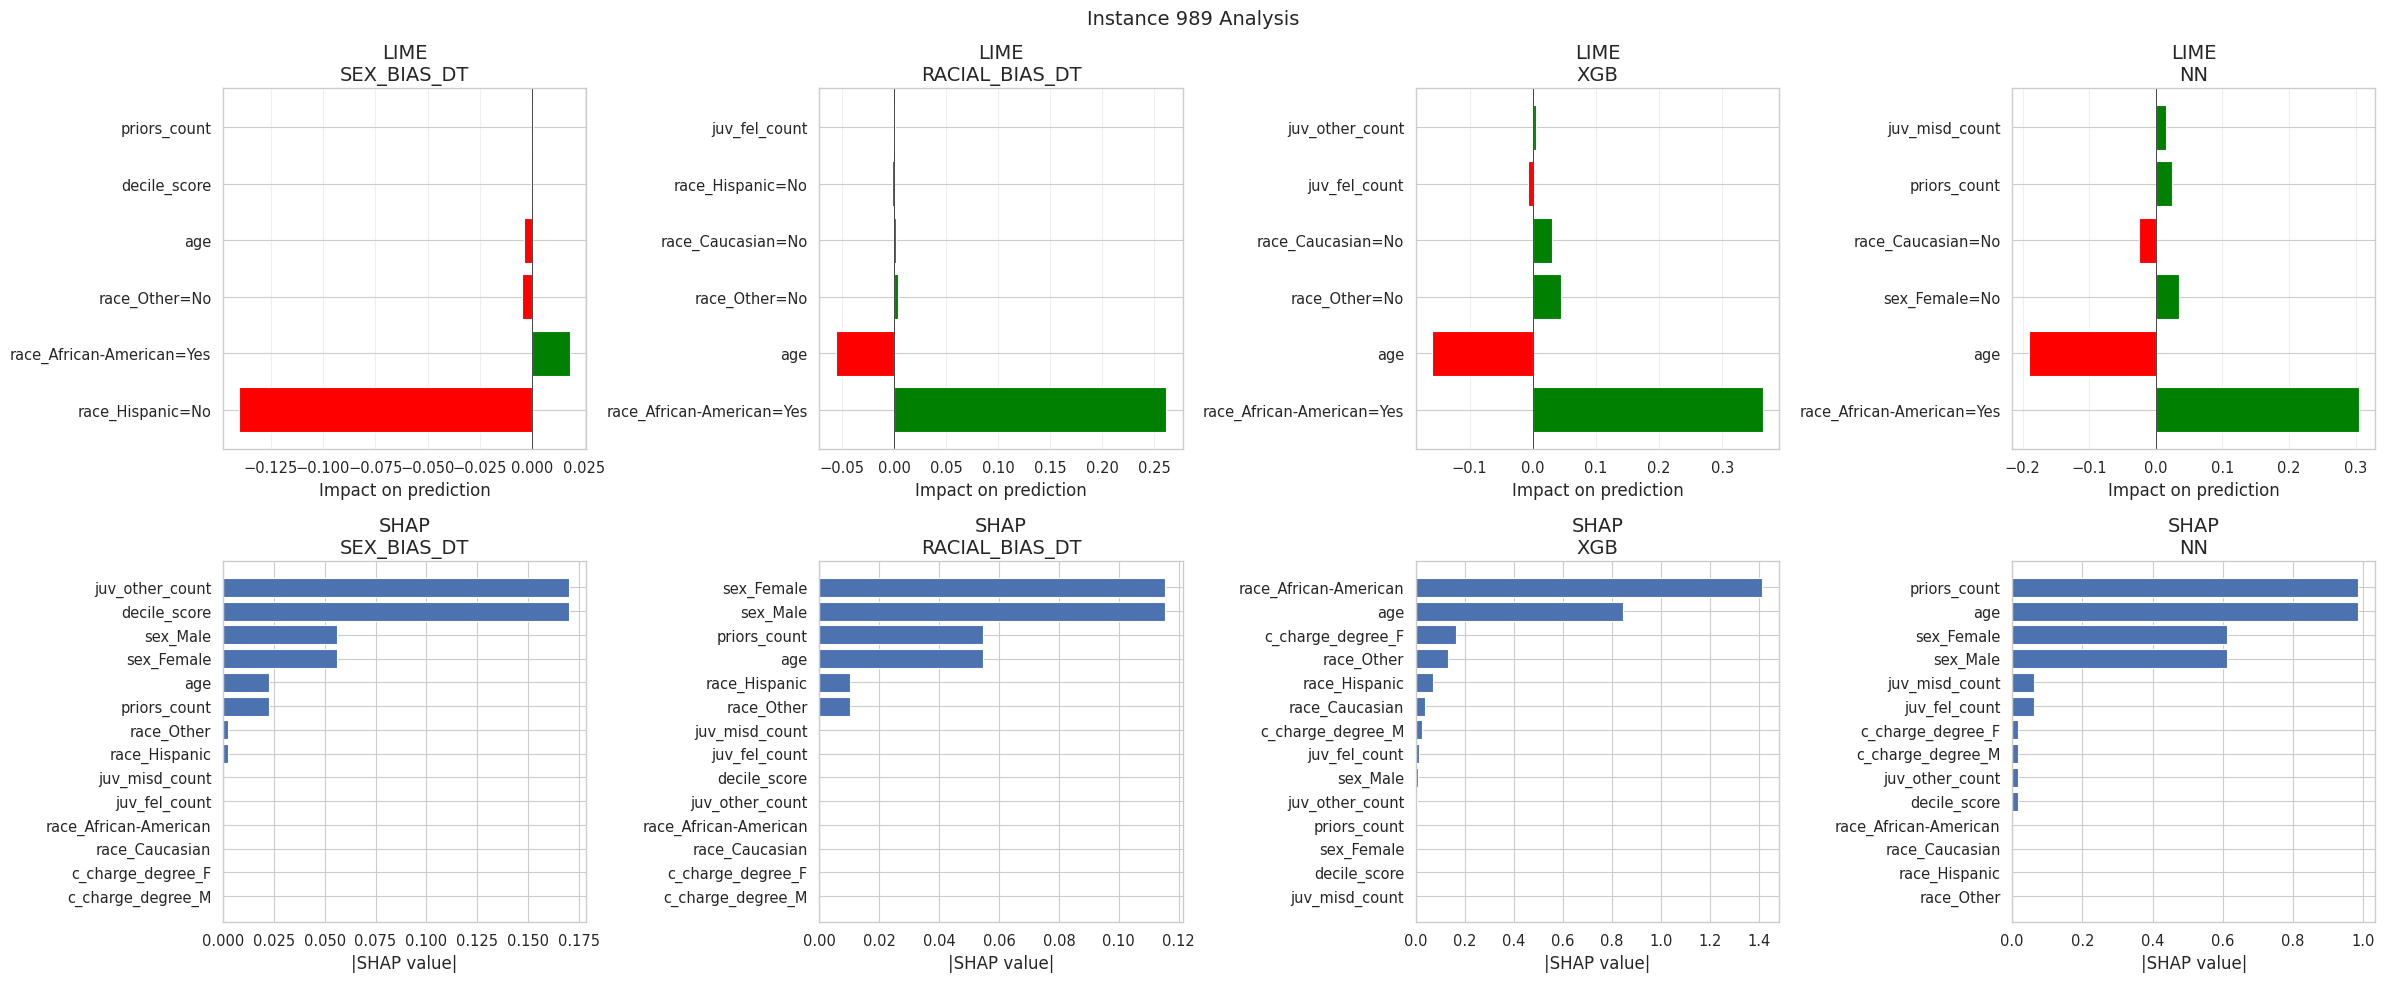


Instance 2434 (True label: Recidivism)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Debug - Prediction shapes:
Sex Bias DT pred shape: (1, 2)
Racial Bias DT pred shape: (1, 2)
XGB pred shape: (1, 2)
NN pred shape: (1, 1)

Predictions:
----------------------------------------
SEX_BIAS_DT     : 0.340
RACIAL_BIAS_DT  : 0.685
XGB             : 0.917
NN              : 0.932


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



Debug info for sex_bias_dt:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)

SEX_BIAS_DT SHAP Values:
SHAP array shape: (14,)
  juv_other_count                : +0.170
  decile_score                   : -0.170
  sex_Male                       : +0.056
  sex_Female                     : -0.056
  age                            : -0.022
  priors_count                   : +0.022

Debug info for racial_bias_dt:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)

RACIAL_BIAS_DT SHAP Values:
SHAP array shape: (14,)
  sex_Female                     : -0.116
  sex_Male                       : +0.116
  priors_count                   : +0.055
  age                            : -0.055
  race_Hispanic                  : +0.010
  race_Other                     : -0.010


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



Debug info for xgb:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14)

XGB SHAP Values:
SHAP array shape: (14,)
  race_African-American          : +1.411
  age                            : +0.847
  c_charge_degree_F              : +0.163
  race_Other                     : +0.130
  race_Hispanic                  : -0.069
  race_Caucasian                 : +0.037
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

Debug info for nn:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)

NN SHAP Values:
SHAP array shape: (14,)
  priors_count                   : +1.246
  age                            : -1.246
  sex_Female                     : -0.612
  sex_Male                       : +0.612
  juv_fel_count                  : +0.064
  juv_misd_count                 : -0.064


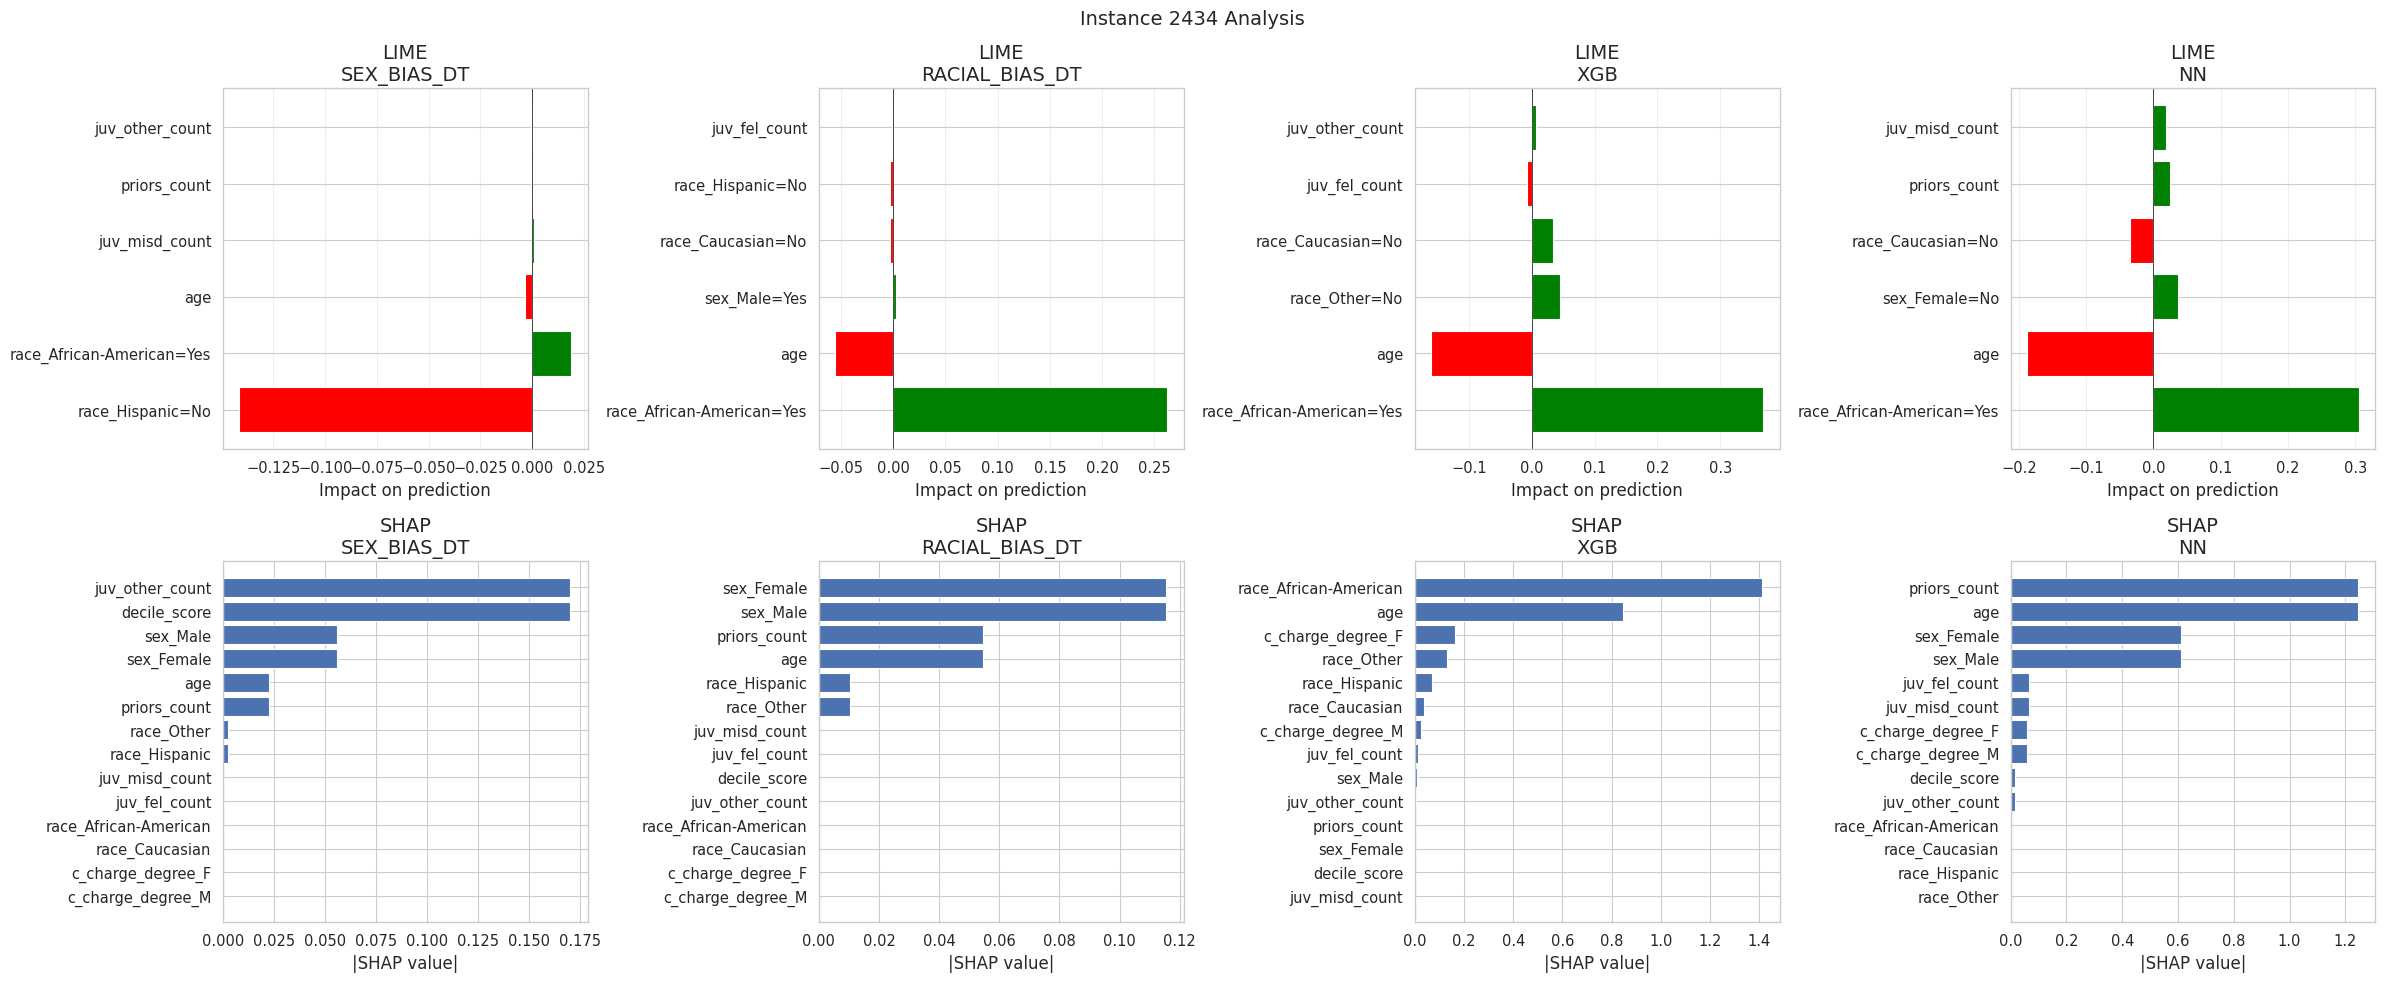


Instance 240 (True label: No Recidivism)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



Debug - Prediction shapes:
Sex Bias DT pred shape: (1, 2)
Racial Bias DT pred shape: (1, 2)
XGB pred shape: (1, 2)
NN pred shape: (1, 1)

Predictions:
----------------------------------------
SEX_BIAS_DT     : 0.340
RACIAL_BIAS_DT  : 0.562
XGB             : 0.546
NN              : 0.410


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



Debug info for sex_bias_dt:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)

SEX_BIAS_DT SHAP Values:
SHAP array shape: (14,)
  juv_other_count                : +0.107
  decile_score                   : -0.107
  sex_Male                       : +0.042
  sex_Female                     : -0.042
  priors_count                   : -0.027
  age                            : +0.027

Debug info for racial_bias_dt:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)

RACIAL_BIAS_DT SHAP Values:
SHAP array shape: (14,)
  sex_Female                     : -0.126
  sex_Male                       : +0.126
  age                            : +0.084
  priors_count                   : -0.084
  race_Hispanic                  : +0.005
  race_Other                     : -0.005

Debug info for xgb:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14)

XGB SHAP Values:
SHAP array shape: (14,)
  race_African-American          : +1.469
  age         

  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Debug info for nn:
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 14, 2)

NN SHAP Values:
SHAP array shape: (14,)
  age                            : +1.907
  priors_count                   : -1.907
  sex_Female                     : -0.708
  sex_Male                       : +0.708
  juv_misd_count                 : -0.097
  juv_fel_count                  : +0.097


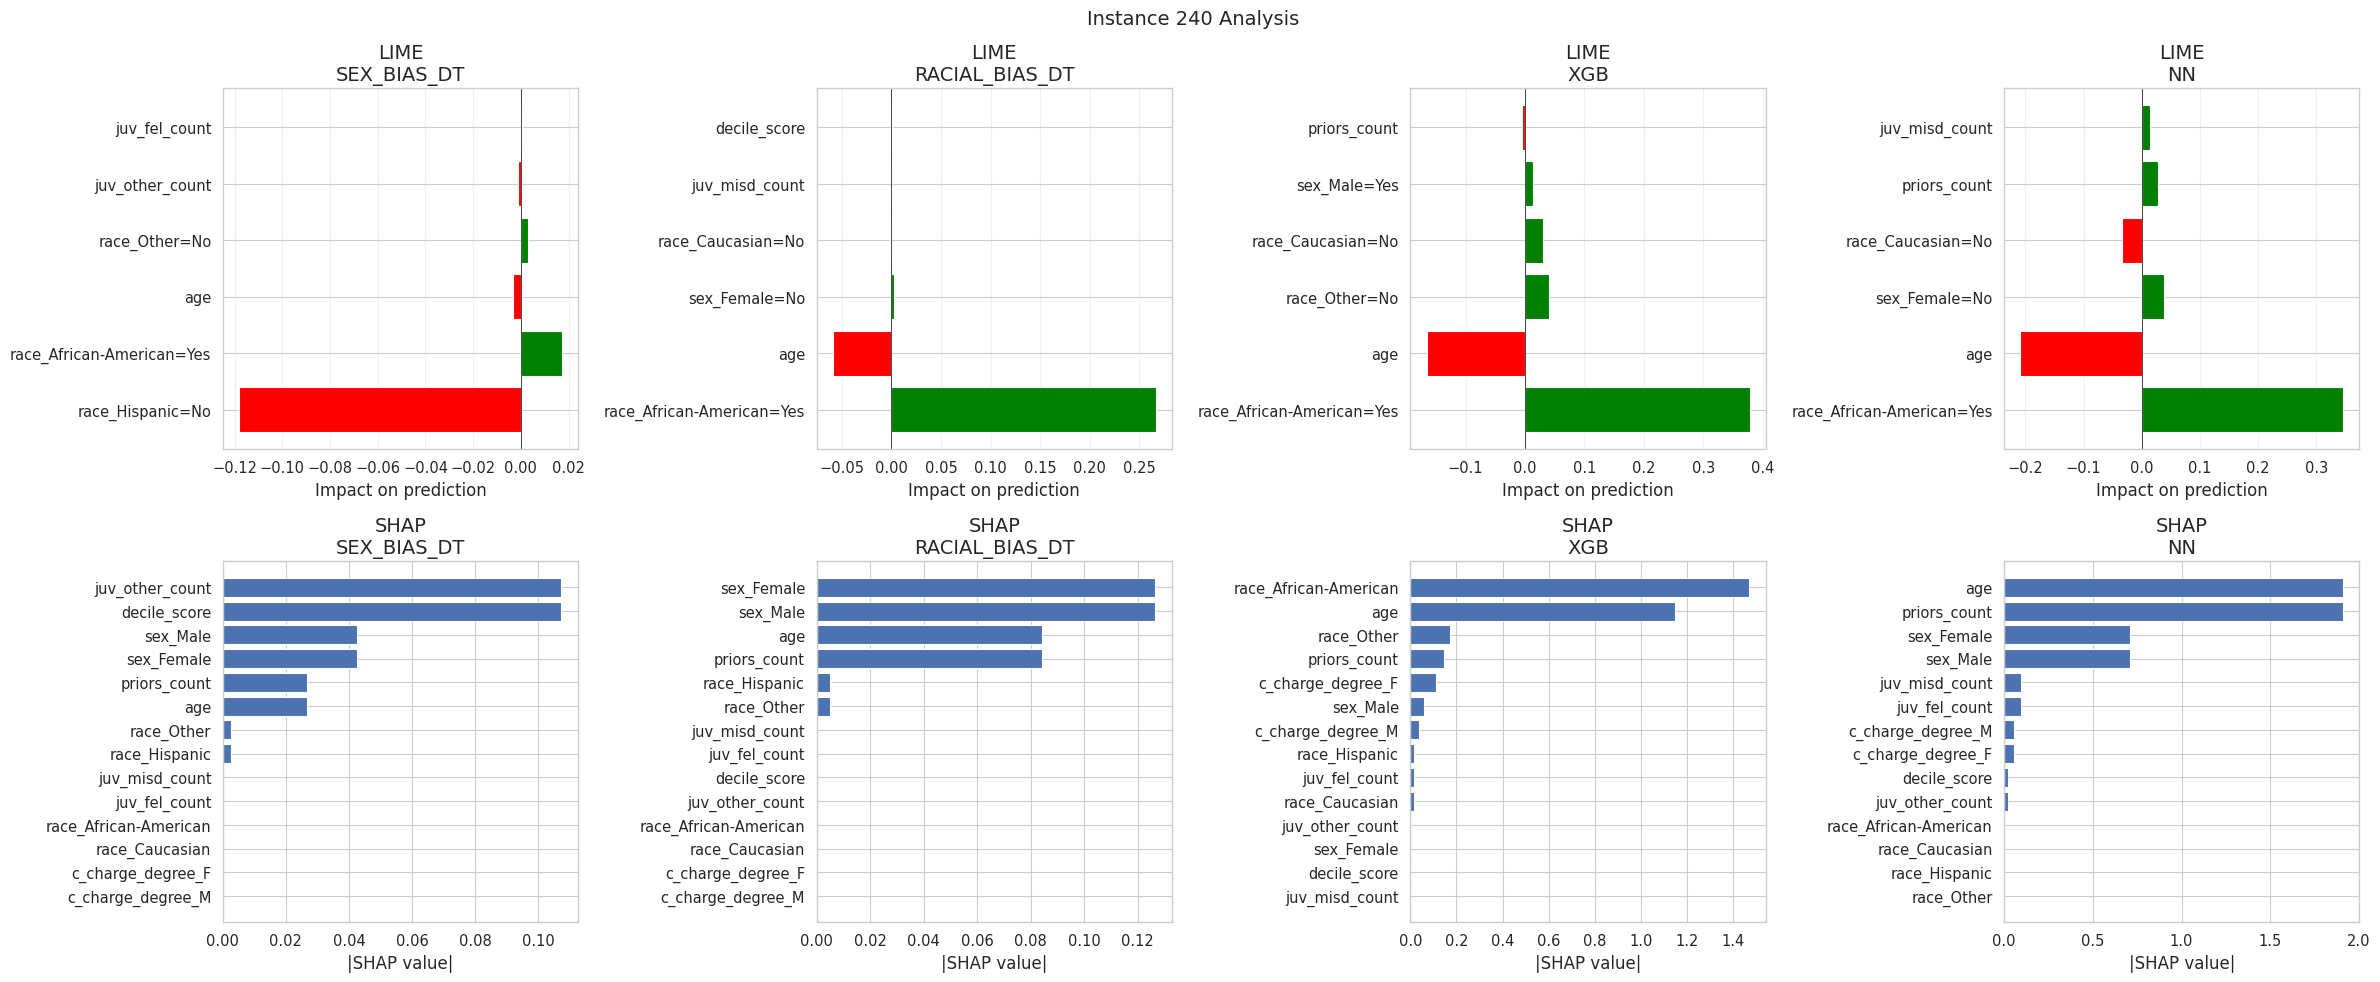

In [45]:
# Run LIME and SHAP Analysis

# Analyze random instances
print("\nAnalyzing 5 random instances...")
random_indices = np.random.choice(len(X_test), 5, replace=False)

for idx in random_indices:
    instance = X_test.iloc[idx]
    true_label = y_test.iloc[idx]

    print("\n" + "="*80)
    print(f"Instance {idx} (True label: {'Recidivism' if true_label == 1 else 'No Recidivism'})")
    print("="*80)

    # Get predictions with proper type conversion
    instance_reshaped = instance.values.reshape(1, -1).astype(np.float32)

    # Get predictions for each model
    try:
        # For tree-based models, get probability of positive class
        sex_bias_pred = models_dict['sex_bias_dt'].predict_proba(instance_reshaped)[0, 1]
        racial_bias_pred = models_dict['racial_bias_dt'].predict_proba(instance_reshaped)[0, 1]
        xgb_pred = models_dict['xgb'].predict_proba(instance_reshaped)[0, 1]

        # For neural network, handle single output
        nn_output = models_dict['nn'].predict(instance_reshaped)
        if nn_output.shape[1] > 1:  # If multiple outputs (probabilities)
            nn_pred = nn_output[0, 1]  # Take probability of positive class
        else:  # If single output (logits/probability)
            nn_pred = nn_output[0, 0]  # Take the single value

        preds = {
            'sex_bias_dt': float(sex_bias_pred),
            'racial_bias_dt': float(racial_bias_pred),
            'xgb': float(xgb_pred),
            'nn': float(nn_pred)
        }

        print("\nDebug - Prediction shapes:")
        print(f"Sex Bias DT pred shape: {models_dict['sex_bias_dt'].predict_proba(instance_reshaped).shape}")
        print(f"Racial Bias DT pred shape: {models_dict['racial_bias_dt'].predict_proba(instance_reshaped).shape}")
        print(f"XGB pred shape: {models_dict['xgb'].predict_proba(instance_reshaped).shape}")
        print(f"NN pred shape: {nn_output.shape}")
    except Exception as e:
        print(f"Error getting predictions: {str(e)}")
        print(f"Shape of instance: {instance_reshaped.shape}")
        print(f"Neural network prediction shape: {models_dict['nn'].predict(instance_reshaped).shape}")
        raise

    # Print predictions
    print("\nPredictions:")
    print("-" * 40)
    for name, pred in preds.items():
        print(f"{name.upper():15} : {pred:.3f}")

    # Create figure for visualizations
    fig, axes = plt.subplots(2, 4, figsize=(24, 10))
    fig.suptitle(f'Instance {idx} Analysis', fontsize=14)

    # Get LIME explanations
    for i, (name, model) in enumerate(models_dict.items()):
        # Define prediction function based on model type
        if name == 'nn':
            # For neural network, wrap the prediction to match expected format
            def nn_predict_fn(x):
                pred = model.predict(x.astype(np.float32))
                if pred.shape[1] == 1:
                    # If single output, convert to two-class probability
                    return np.hstack([1 - pred, pred])
                return pred
            predict_fn = nn_predict_fn
        else:
            predict_fn = model.predict_proba

        exp = lime_exp.explain_instance(instance.values.astype(np.float32), predict_fn, num_features=6)

        # Plot LIME explanation directly
        plt.sca(axes[0, i])
        exp_list = exp.as_list()
        features, values = zip(*exp_list)
        values = [float(v) for v in values]  # Convert to Python floats
        colors = ['green' if v > 0 else 'red' for v in values]
        y_pos = np.arange(len(features))

        # Create horizontal bar chart for LIME
        axes[0, i].barh(y_pos, values, align='center', color=colors)
        axes[0, i].set_yticks(y_pos)
        axes[0, i].set_yticklabels([str(x) for x in features])
        axes[0, i].set_xlabel('Impact on prediction')
        axes[0, i].set_title(f'LIME\n{name.upper()}')
        axes[0, i].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        axes[0, i].grid(True, axis='x', alpha=0.3)

        # Get SHAP values
        try:
            shap_values = shap_exp[name].shap_values(instance_reshaped)

            # Print debug info
            print(f"\nDebug info for {name}:")
            print(f"SHAP values type: {type(shap_values)}")
            if isinstance(shap_values, list):
                print(f"SHAP values list length: {len(shap_values)}")
                for i, sv in enumerate(shap_values):
                    print(f"Shape of element {i}: {sv.shape if hasattr(sv, 'shape') else 'no shape'}")
            else:
                print(f"SHAP values shape: {shap_values.shape}")

            # Handle SHAP values based on model type
            if isinstance(shap_values, list):
                # For models that return a list of arrays (one per class)
                if len(shap_values) >= 2:
                    # Take positive class values
                    shap_array = shap_values[1]
                else:
                    # If only one array, use it
                    shap_array = shap_values[0]
            else:
                # For models that return a single array
                shap_array = shap_values

            # Ensure we have the right shape
            if isinstance(shap_array, np.ndarray):
                if shap_array.ndim > 2:
                    shap_array = shap_array.reshape(-1, len(feature_names))
                if shap_array.ndim == 2:
                    shap_array = shap_array[0]  # Take first instance

            # Ensure shap_array is 1D and matches feature_names length
            shap_array = np.array(shap_array).ravel()
            if len(shap_array) != len(feature_names):
                raise ValueError(f"SHAP values length ({len(shap_array)}) doesn't match feature count ({len(feature_names)})")

            # Create horizontal bar chart for SHAP
            plt.sca(axes[1, i])
            importance_values = np.abs(shap_array)

            # Sort by absolute importance
            sort_idx = np.argsort(importance_values)
            sorted_features = [feature_names[j] for j in sort_idx]
            sorted_importance = importance_values[sort_idx]
            y_pos = np.arange(len(sorted_features))

            # Create the plot
            axes[1, i].barh(y_pos, sorted_importance)
            axes[1, i].set_yticks(y_pos)
            axes[1, i].set_yticklabels(sorted_features)
            axes[1, i].set_title(f'SHAP\n{name.upper()}')
            axes[1, i].set_xlabel('|SHAP value|')

            # Print SHAP values
            print(f"\n{name.upper()} SHAP Values:")
            print(f"SHAP array shape: {shap_array.shape}")
            sorted_pairs = sorted(zip(feature_names, shap_array), key=lambda x: abs(x[1]), reverse=True)
            for feat, value in sorted_pairs[:6]:
                print(f"  {str(feat):30} : {float(value):+.3f}")

        except Exception as e:
            print(f"\nError calculating SHAP values for {name}: {str(e)}")
            # Fill the plot with a message
            axes[1, i].text(0.5, 0.5, 'SHAP values\nnot available',
                          horizontalalignment='center',
                          verticalalignment='center',
                          transform=axes[1, i].transAxes)
            axes[1, i].set_title(f'SHAP\n{name.upper()}')

    plt.tight_layout()
    plt.show()


114/157 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 878us/step
112/157 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 927us/step
 58/157 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 2s 941us/step


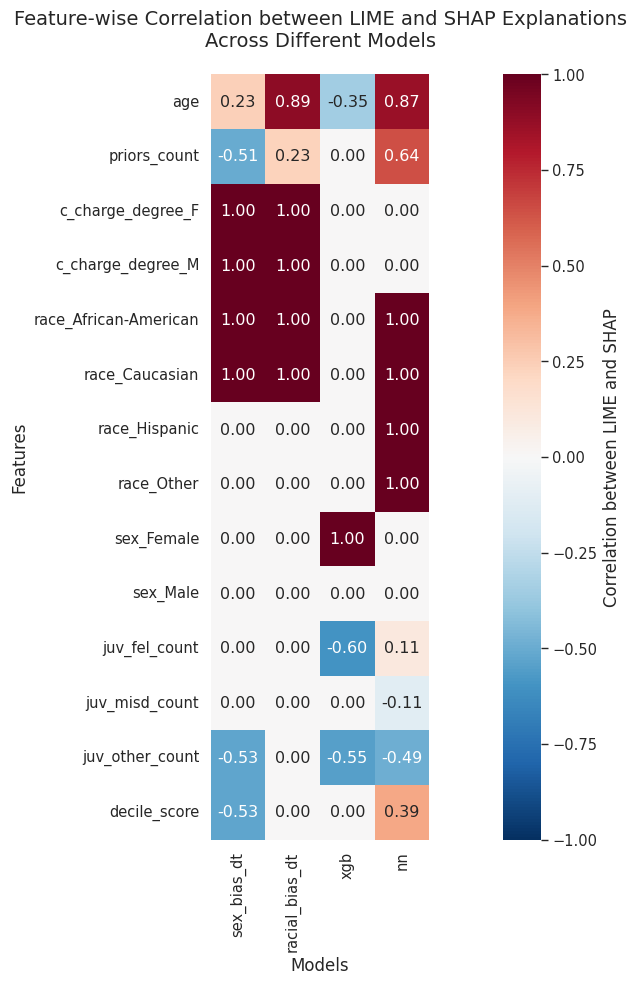


Summary of LIME vs SHAP Agreement by Feature:
--------------------------------------------------

Features ranked by consistency between LIME and SHAP:
race_African-American     Mean correlation:  0.750 ± 0.500 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT, XGB, NN)
race_Caucasian            Mean correlation:  0.750 ± 0.500 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT, XGB, NN)
c_charge_degree_M         Mean correlation:  0.500 ± 0.577 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT, XGB, NN)
c_charge_degree_F         Mean correlation:  0.500 ± 0.577 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT, XGB, NN)
age                       Mean correlation:  0.412 ± 0.590
race_Hispanic             Mean correlation:  0.250 ± 0.500 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT, XGB, NN)
sex_Female                Mean correlation:  0.250 ± 0.500 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT, XGB, NN)
race_Other                Mean correlation:  0.250 ± 0.500 (Constant values in: 

In [50]:
# Create correlation heatmap between LIME and SHAP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Initialize correlation matrices for each model
correlation_data = {}

def safe_correlation(x, y):
    """Calculate correlation with handling for constant arrays"""
    # Check if either array is constant
    if np.all(x == x[0]) or np.all(y == y[0]):
        if np.array_equal(x, y):  # If both arrays are identical constants
            return 1.0
        else:  # If only one array is constant or they're different constants
            return 0.0
    else:
        return stats.pearsonr(x, y)[0]

# Suppress specific warning about constant input
warnings.filterwarnings('ignore', category=stats.ConstantInputWarning)

# Select random instances for analysis
np.random.seed(42)  # for reproducibility
n_instances = 5
random_indices = np.random.choice(len(X_test), n_instances, replace=False)
test_instances = X_test.iloc[random_indices]

# Initialize storage for explanations
lime_explanations = {
    'sex_bias_dt': [], 'racial_bias_dt': [], 'xgb': [], 'nn': []
}
shap_explanations = {
    'sex_bias_dt': [], 'racial_bias_dt': [], 'xgb': [], 'nn': []
}

# Get explanations for each instance
for idx, instance in test_instances.iterrows():
    instance_reshaped = instance.values.reshape(1, -1).astype(np.float32)

    # Get LIME explanations
    for name, model in models_dict.items():
        if name == 'nn':
            predict_fn = lambda x: np.hstack([1 - model.predict(x.astype(np.float32)),
                                          model.predict(x.astype(np.float32))])
        else:
            predict_fn = model.predict_proba

        exp = lime_exp.explain_instance(
            instance.values.astype(np.float32),
            predict_fn,
            num_features=len(feature_names)
        )
        lime_values = dict(exp.as_list())
        lime_explanations[name].append([lime_values.get(f, 0) for f in feature_names])

    # Get SHAP explanations
    for name, explainer in shap_exp.items():
        shap_values = explainer.shap_values(instance_reshaped)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        shap_values = shap_values.reshape(-1)
        shap_explanations[name].append(shap_values)

# Convert explanations to numpy arrays
for name in models_dict.keys():
    lime_vals = np.abs(np.array(lime_explanations[name]))
    shap_vals = np.abs(np.array(shap_explanations[name]))

    # Calculate correlation for each feature
    correlations = []
    for i in range(len(feature_names)):
        corr = safe_correlation(lime_vals[:, i], shap_vals[:, i])
        correlations.append(corr)

    correlation_data[name] = correlations

# Create DataFrame with correlations
correlation_df = pd.DataFrame(correlation_data, index=feature_names)

# Create heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_df,
            cmap='RdBu_r',  # Red-Blue diverging colormap
            center=0,       # Center the colormap at 0
            vmin=-1,       # Minimum correlation
            vmax=1,        # Maximum correlation
            annot=True,    # Show correlation values
            fmt='.2f',     # Format for correlation values
            square=True,   # Make cells square
            cbar_kws={'label': 'Correlation between LIME and SHAP'})

plt.title('Feature-wise Correlation between LIME and SHAP Explanations\nAcross Different Models', pad=20)
plt.xlabel('Models')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print summary statistics with additional information
print("\nSummary of LIME vs SHAP Agreement by Feature:")
print("-" * 50)

# Calculate mean correlation across models for each feature
mean_correlations = correlation_df.mean(axis=1)
std_correlations = correlation_df.std(axis=1)

# Sort features by average correlation
sorted_features = mean_correlations.sort_values(ascending=False)

print("\nFeatures ranked by consistency between LIME and SHAP:")
for feature in sorted_features.index:
    mean_corr = mean_correlations[feature]
    std_corr = std_correlations[feature]

    # Check if feature has any constant values
    constant_models = []
    for model in correlation_df.columns:
        lime_const = np.all(np.abs(lime_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(lime_explanations[model])[0, feature_names.index(feature)])
        shap_const = np.all(np.abs(shap_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(shap_explanations[model])[0, feature_names.index(feature)])
        if lime_const or shap_const:
            constant_models.append(model.upper())

    print(f"{feature:<25} Mean correlation: {mean_corr:6.3f} ± {std_corr:4.3f}", end="")
    if constant_models:
        print(f" (Constant values in: {', '.join(constant_models)})")
    else:
        print()

# Print model-wise statistics
print("\nModel-wise Agreement Statistics:")
print("-" * 50)
for model in correlation_df.columns:
    corrs = correlation_df[model]
    print(f"\n{model.upper()} Model:")
    print(f"Average correlation: {corrs.mean():.3f}")
    print(f"Correlation std: {corrs.std():.3f}")

    # Count features with constant values
    constant_features = []
    for feature in feature_names:
        lime_const = np.all(np.abs(lime_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(lime_explanations[model])[0, feature_names.index(feature)])
        shap_const = np.all(np.abs(shap_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(shap_explanations[model])[0, feature_names.index(feature)])
        if lime_const or shap_const:
            constant_features.append(feature)

    if constant_features:
        print(f"Features with constant values: {len(constant_features)}")
        print("Constant features:", ", ".join(constant_features))

    print(f"Features with highest agreement:")
    top_features = corrs.sort_values(ascending=False).head(3)
    for feat, corr in top_features.items():
        print(f"  {feat:<25} Correlation: {corr:.3f}")



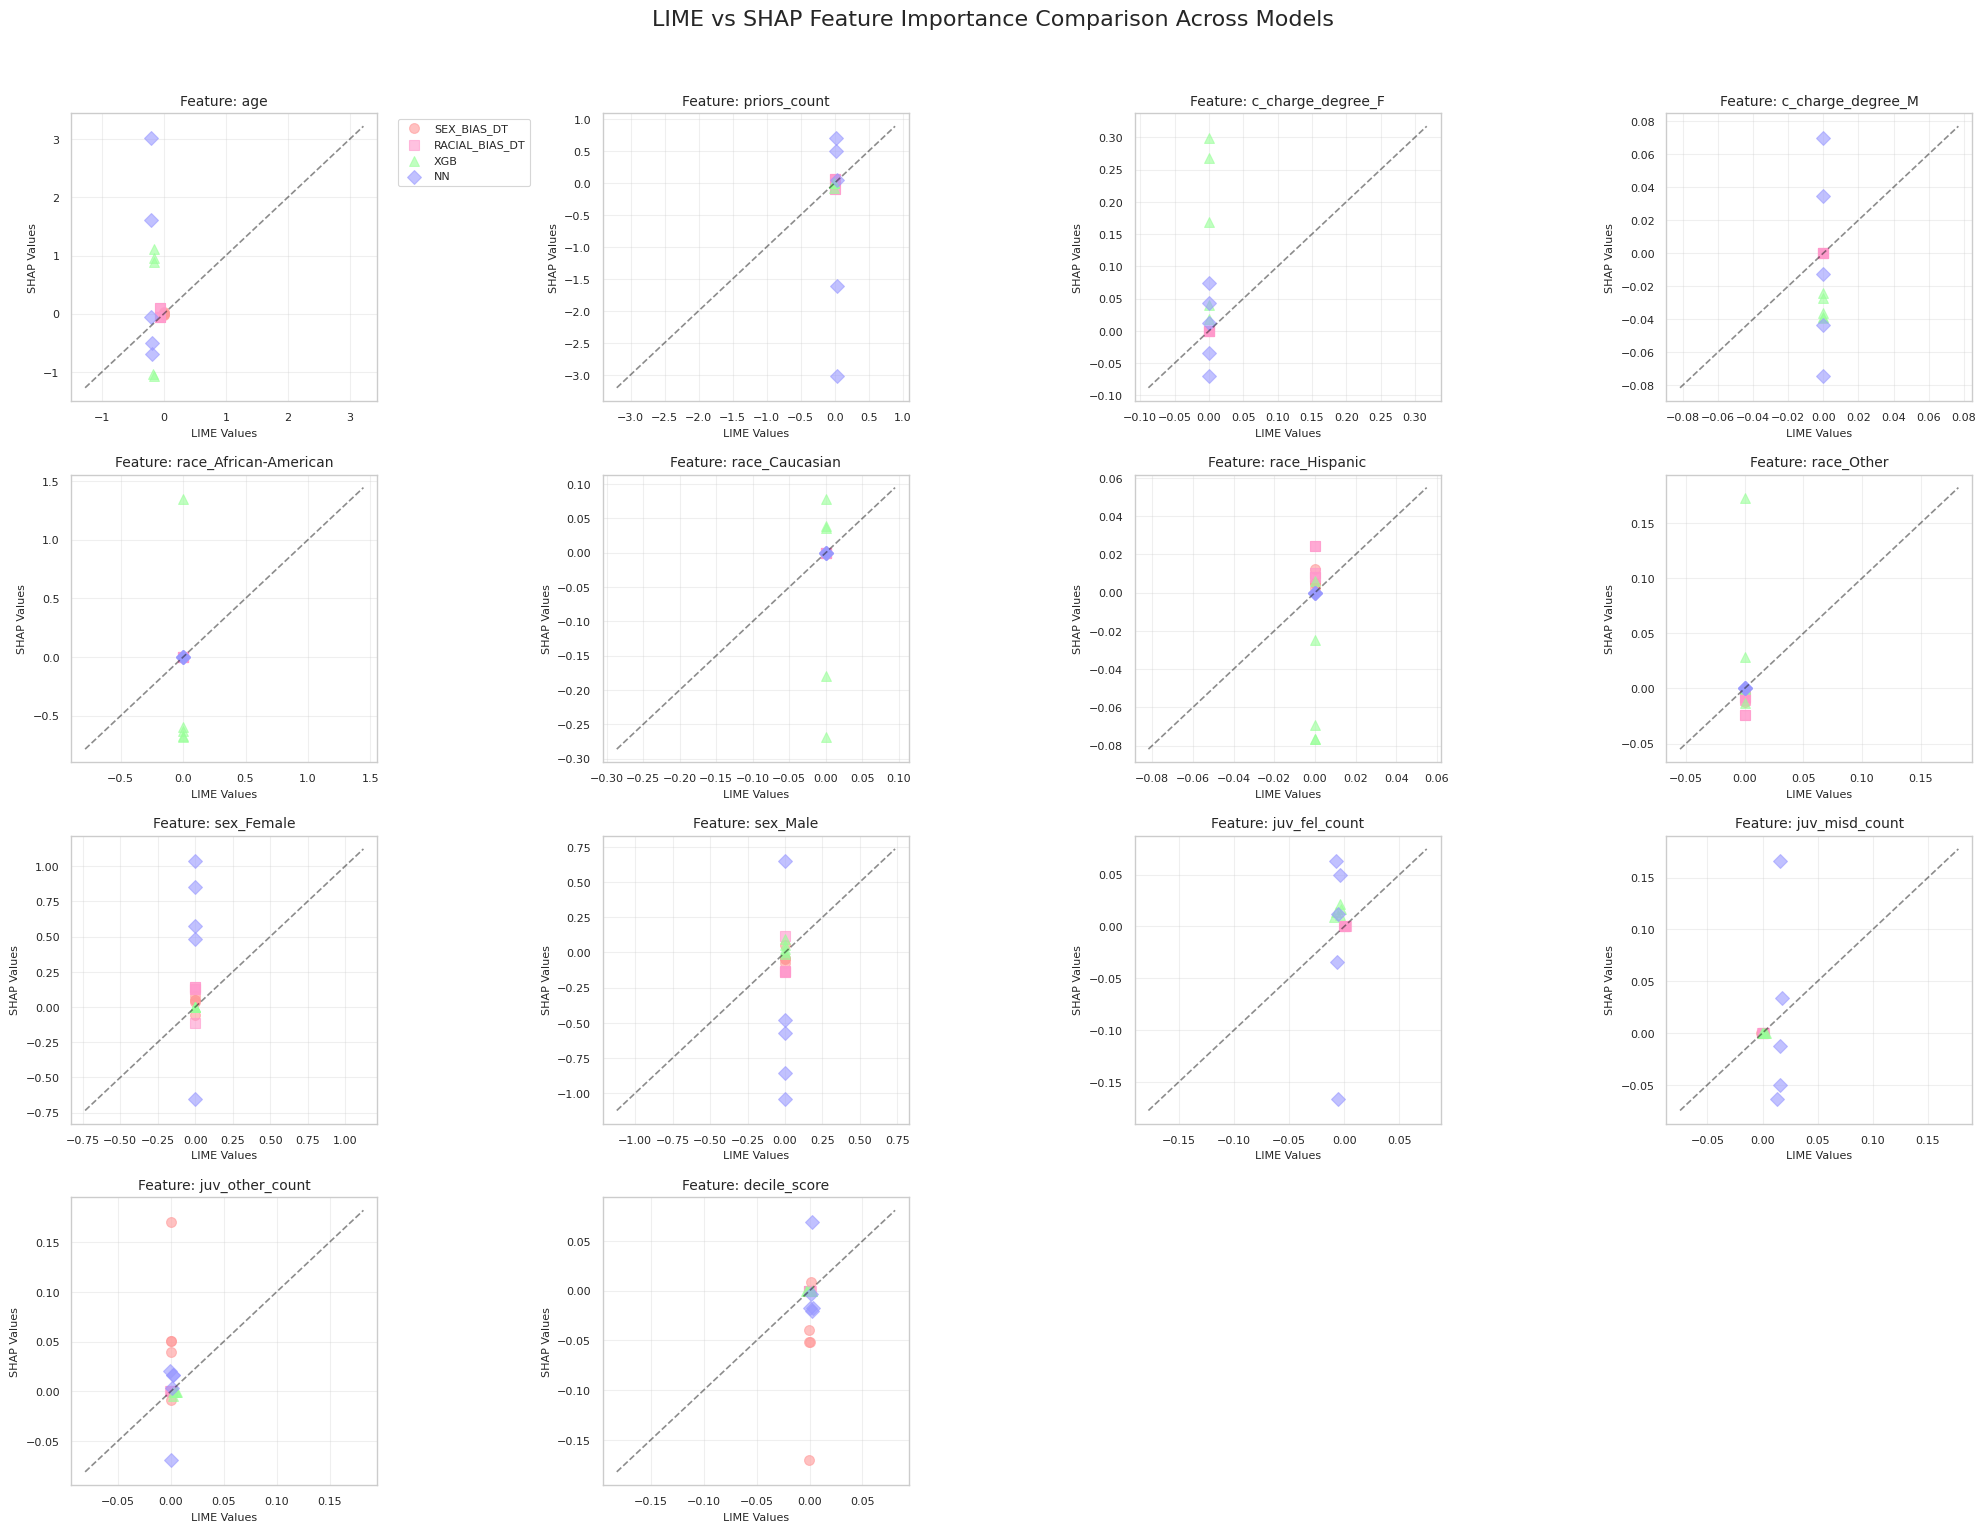

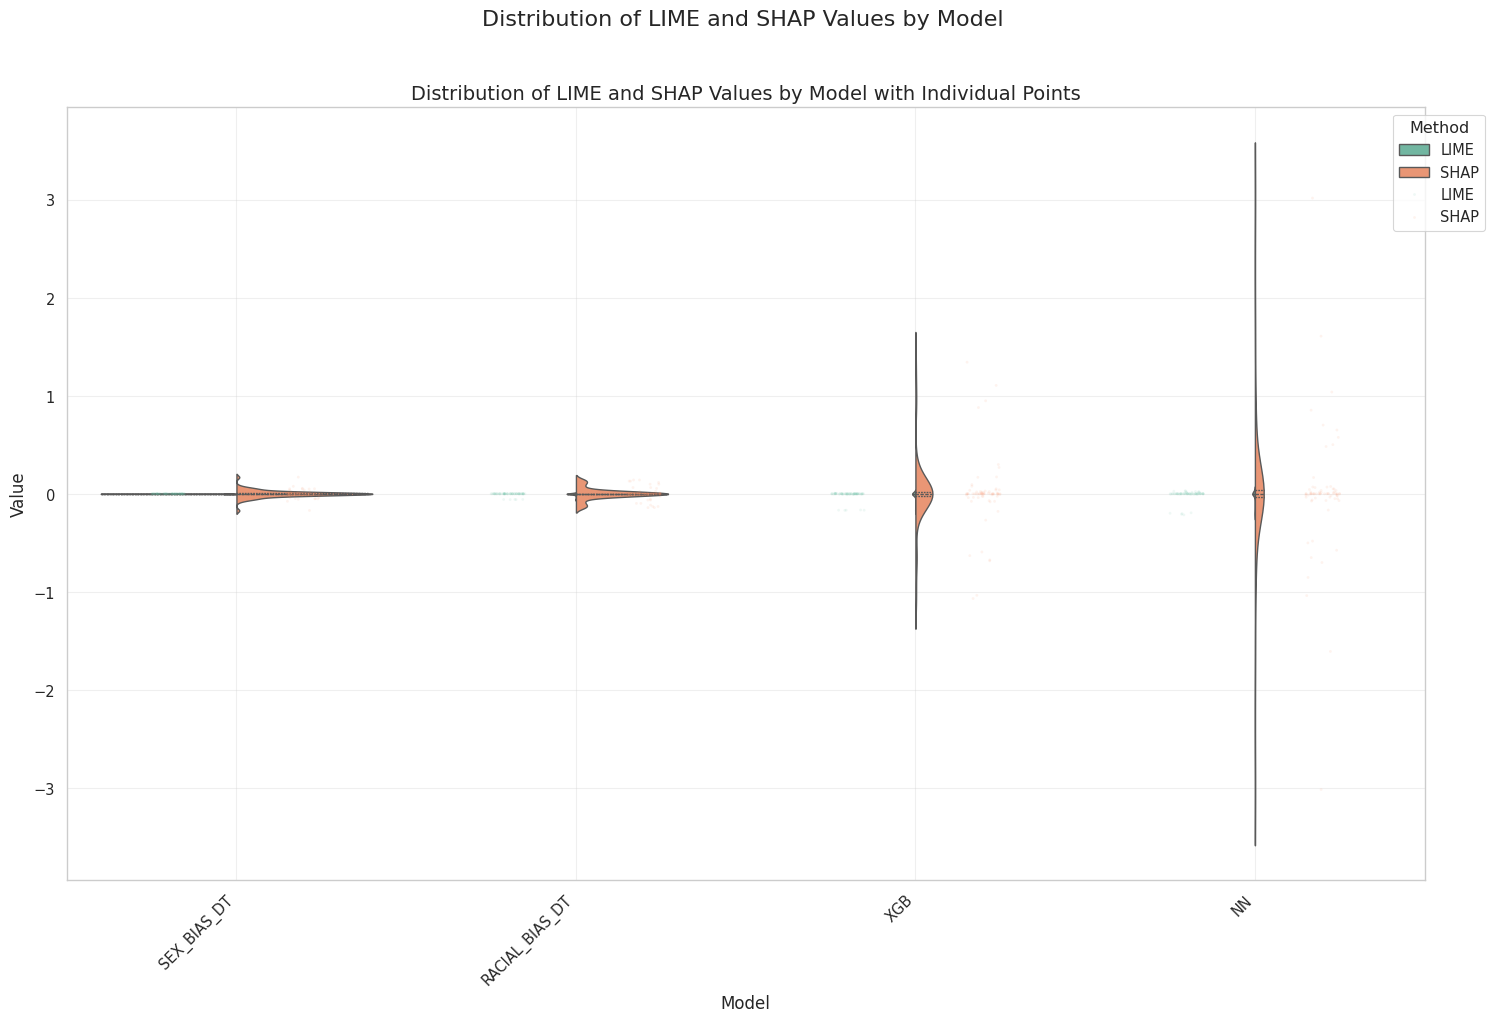

In [53]:
# Define model categories and their colors
model_categories = {
    'sex_bias_dt': {'category': 'Bias-Specific', 'color': '#FF9999', 'marker': 'o'},
    'racial_bias_dt': {'category': 'Bias-Specific', 'color': '#FF99CC', 'marker': 's'},
    'xgb': {'category': 'General', 'color': '#99FF99', 'marker': '^'},
    'nn': {'category': 'General', 'color': '#9999FF', 'marker': 'D'}
}

# 1. Feature-wise Comparison Plot
plt.figure(figsize=(20, 15))
plt.suptitle('LIME vs SHAP Feature Importance Comparison Across Models', fontsize=16, y=1.02)

for i, feature_idx in enumerate(range(len(feature_names))):
    plt.subplot(4, 4, i+1)  # Adjust grid size based on number of features

    for name in models_dict.keys():
        lime_vals = np.array([x[feature_idx] for x in lime_explanations[name]])
        shap_vals = np.array([x[feature_idx] for x in shap_explanations[name]])

        plt.scatter(lime_vals, shap_vals,
                   alpha=0.6,
                   c=model_categories[name]['color'],
                   marker=model_categories[name]['marker'],
                   label=name.upper(),
                   s=50)  # Adjust point size

    plt.title(f'Feature: {feature_names[feature_idx]}', fontsize=10)
    plt.xlabel('LIME Values', fontsize=8)
    plt.ylabel('SHAP Values', fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=8)

    if i == 0:  # Only show legend for first subplot
        plt.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
    plt.grid(True, alpha=0.3)

    # Add diagonal reference line
    lims = [
        min(plt.xlim()[0], plt.ylim()[0]),
        max(plt.xlim()[1], plt.ylim()[1])
    ]
    plt.plot(lims, lims, 'k--', alpha=0.5)

plt.tight_layout()
plt.show()

# 3. Violin Plot with Individual Points
# Prepare data for violin plot
comparison_data = []
for name in models_dict.keys():
    for feature_idx in range(len(feature_names)):
        lime_vals = np.array([x[feature_idx] for x in lime_explanations[name]])
        shap_vals = np.array([x[feature_idx] for x in shap_explanations[name]])

        comparison_data.extend([
            {'Model': name.upper(), 'Method': 'LIME', 'Feature': feature_names[feature_idx], 'Value': v}
            for v in lime_vals
        ])
        comparison_data.extend([
            {'Model': name.upper(), 'Method': 'SHAP', 'Feature': feature_names[feature_idx], 'Value': v}
            for v in shap_vals
        ])

df_comparison = pd.DataFrame(comparison_data)

# Create violin plot with individual points
plt.figure(figsize=(15, 10))
plt.suptitle('Distribution of LIME and SHAP Values by Model', fontsize=16, y=1.02)

# Create violin plot
sns.violinplot(data=df_comparison, x='Model', y='Value', hue='Method',
               split=True, inner='quart', palette='Set2')

# Add individual points
sns.stripplot(data=df_comparison, x='Model', y='Value', hue='Method',
              dodge=True, alpha=0.1, size=2, palette='Set2')

plt.title('Distribution of LIME and SHAP Values by Model with Individual Points')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.legend(title='Method', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()